# Equivalent Consumption Minimization Strategy (ECMS)

Instantaneous strategy: at every step the control minimizes a scalar equivalent fuel cost
(real fuel + equivalence factor · battery power + `R_int` loss term), with no recursion and
no knowledge of the future beyond the present state.

The equivalence factor `s(k)` is anchored at the analytical break-even value 1/η_ICE = 2.008
and adjusted by proportional feedback on a SoC reference trajectory. That reference is the
single-lap DP's own optimal trajectory, which makes this an **upper bound on achievable ECMS
performance** rather than a fully causal controller: the instantaneous minimization is
online, but the reference it tracks is not. This is deliberate — it isolates the cost of
giving up the multi-stage recursion from the cost of giving up a good reference. A fully
causal variant (linear depletion schedule, no DP input) is left as future work.

Charge-sustaining bisection on `s` is not applied, since it has no meaning over a single
isolated qualifying lap with a free terminal SoC.

**Inputs**: `data/qualifying_Canada/` velocity profile, DP SoC reference \
**Outputs**: `ECMS_Canada_qualifying.npz`, SoC/power trajectory plots \
**Depends on**: `plant/battery.py`, `plant/powertrain.py`

### ECMS — Equivalent Consumption Minimization Strategy

Unlike DP, ECMS does **not** solve a multi-stage recursion. At every timestep $k$ it solves a
**single-instant** minimization using only the present state $(SoC(k), E_{ES2K}(k))$.

**Control variable and unit convention**

As in the DP formulation, the optimization variable is the **electrical** power at the
battery terminals, $P_2$, which is the quantity limited by regulation. The power-split
constraints are **mechanical**, and the two are related by the MGU-K efficiency with a
direction-dependent conversion:

$$
P_{mech} = \eta_{MGU} P_2 \quad (P_2 > 0), \qquad
P_{mech} = \frac{P_2}{\eta_{MGU}} \quad (P_2 < 0)
$$

**Equivalent fuel cost (instantaneous)**

$$
\dot{m}_{eq}(k) = \dot{m}_{ICE}(k) \;+\; \frac{s(k)}{H_{lhv}} \, P_{2}(k)
\;+\; \frac{1}{H_{lhv}} \left( \frac{P_{2}(k)}{U_{oc}(SoC)} \right)^2 R_{int}
$$

The first term is the real fuel burned by the ICE. The second is a *virtual* fuel cost
assigned to using the battery through the **equivalence factor** $s(k)$, which converts a
Joule of electrical energy into an equivalent mass of fuel so the two can be compared at
every instant. The third charges the ohmic loss of drawing that power.

**Per-step optimization problem**

$$
P_{2}^*(k) = \arg\min_{P_{2}(k) \,\in\, [lb(k),\,ub(k)]}
\dot{m}_{ICE}\big(P_{gb}(k) - \eta_{MGU} P_{2}(k)\big)
+ \frac{s(k)}{H_{lhv}} P_{2}(k)
+ \frac{1}{H_{lhv}} \left( \frac{P_{2}(k)}{U_{oc}(SoC)} \right)^2 R_{int}
$$

**Bounds** — identical physics to the DP formulation (the ICE cannot absorb negative power;
excess braking power is dissipated by the mechanical brakes at no fuel or energy cost):

$$
\begin{cases}
\max\Big( \underline{P}_{SoC}(k),\, P_{MGU\text{-}K}^{min},\, \dfrac{P_{gb}(k) - P_{ICE}^{max}}{\eta_{MGU}} \Big)
\le P_{2}(k) \le
\min\Big( \overline{P}_{SoC}(k),\, \dfrac{E_{ES2K}^{max} - E_{ES2K}(k)}{\Delta t},\, P_{MGU\text{-}K}^{max},\, \dfrac{P_{gb}(k)}{\eta_{MGU}} \Big),
& P_{gb}(k) \ge 0 \\[14pt]
\max\Big( \underline{P}_{SoC}(k),\, P_{MGU\text{-}K}^{min},\, \eta_{MGU} P_{gb}(k) \Big)
\le P_{2}(k) \le \min\big( \overline{P}_{SoC}(k),\, 0 \big),
& P_{gb}(k) < 0
\end{cases}
$$

with

$$
\underline{P}_{SoC}(k) = \frac{(SoC^{max}-SoC(k))\,Q_{bat} U_{oc}(SoC(k))}{-\Delta t},
\qquad
\overline{P}_{SoC}(k) = \frac{(SoC^{min}-SoC(k))\,Q_{bat} U_{oc}(SoC(k))}{-\Delta t}
$$

The bounds use $U_{oc}(SoC_k)$, which depends on the state only, rather than the terminal
voltage $U_2$, which depends on the power being chosen and would make the constraint
circular. $P_{ICE}^{max} = 400$ kW is the nominal cap; it coincides with the
fuel-flow-achievable value $\eta_{ICE} H_{lhv} \dot{m}^{max} - P_{ICE,0}$ because
$\dot{m}^{max}$ was calibrated from it, so the two are numerically identical here.

**State dynamics** (same as DP)

$$
\begin{aligned}
SoC(k+1) &= SoC(k) - \frac{\Delta t}{Q_{bat}\,U_{oc}(SoC)} P_{2}(k)\\
E_{ES2K}(k+1) &= E_{ES2K}(k) + \max(P_{2}(k),0)\,\Delta t
\end{aligned}
$$

**Calibration of $s$**

$s(k)$ is not a single constant found by end-of-lap bisection. It is recomputed at every step
by proportional feedback on the gap between the simulated SoC and the DP reference
trajectory, then clipped to a sensible range:

$$
s(k) = \mathrm{clip}\Big( s_0 - K_p \big(SoC(k) - SoC_{ref}(k)\big),\; 0,\; 5 \Big)
$$

If the simulated SoC falls below the reference, $s(k)$ rises, battery use becomes more
expensive in the virtual cost, and the controller draws less on it; the reverse holds above
the reference.

The choice of $s_0$ is not free. Because $\dot{m}_{ICE}$ is affine in $P_{ICE}$ under the
Willans model, the cost is linear in $P_2$ except for the quadratic loss term, and setting
the derivative to zero gives

$$
P_2^* = \left( \frac{1}{\eta_{ICE}} - s \right) \frac{U_{oc}^2}{2 R_{int}}
$$

so the control saturates at $\pm P_{MGU\text{-}K}^{max}$ unless $s$ stays within roughly
$\pm 0.08$ of the break-even value $1/\eta_{ICE} = 2.008$. Below that value the battery is
always cheaper than the engine, above it never is. $s_0$ is therefore set at the break-even
value and $K_p = 5$ chosen so that the resulting excursions stay inside that band; the run
below keeps $s$ within $[1.90, 2.06]$. An earlier calibration with $s_0 = 1$ and $K_p = 170$
drove $s$ between 0 and 42, producing bang-bang behaviour, 59 sign reversals of the MGU-K
power during traction, and a fuel consumption worse than the rule-based baseline.

In [1]:
import numpy as np
import matplotlib.pyplot as plot
from plant.parameters import params
from plant.powertrain import powertrain
import sys, os
sys.path.append(os.path.abspath('..'))

In [2]:
# Parameters (same convention as the DP notebook)
Delta_t = 0.1

Voc = params['V_oc_nom']
Q_bat = params['E_pack_capacity'] / Voc

P_MGU_max = params['P_MGU_max']   # 350 kW
P_MGU_min = params['P_MGU_min']   # -350 kW
P_eng_max_reg = params['P_ICE_max']  # 400 kW, nominal regulatory cap (NOT used as the bound ceiling, see below)
eta_MGU = params['eta_MGU']

E_ES2K_max = params['E_deploy_max']  # 9 MJ

SOC_min = params['SoC_min']
SOC_max = params['SoC_max']

eta_ICE = params['eta_ICE']
P_ICE0 = params['P_ICE0']
LHV = params['LHV']
m_dot_max = params['m_dot_max'] / 3600.0  # kg/h -> kg/s
P_eng_max = params['P_ICE_max']   # 400[kW]

R_int = params['R_int']
Tbat = params['T_bat_init']


# Load Data: t, v, a
data = np.load('/app/data/qualifying_Canada/Canada_qualifying.npy')

t = data[0,:]
v = data[1,:]
a = data[2,:]

# Load Data: power at the gearbox
data_of_power_gb = np.load('/app/data/qualifying_Canada/power_domand_quali.npy')
P_gb = data_of_power_gb[1,:]

N = len(t)

#### ECMS single-step solver

Given the current state and a fixed equivalence factor `s`, find the
`P_MGU-K(k)` that minimizes the equivalent fuel cost at this instant only.

In [3]:
from plant.battery import battery_step, coef_quad, Uoc, thermal_model

def ecms_bounds(P_gb_k,SoC_k, E_k, params_local, dt):
    """
    Regime-dependent admissible range for P_MGU-K(k). Uses Uoc(SoC_k)
    (open-circuit voltage, state-only) rather than U2 (terminal voltage),
    since U2 depends on the power being chosen and would make this circular.
    """
    Uoc_k = Uoc(SoC_k, coef_quad)


    soc_max_term = ((SOC_max - SoC_k) * Q_bat * Uoc_k) / -dt
    soc_min_term = ((SOC_min - SoC_k) * Q_bat * Uoc_k) / -dt
    E_deploy = (E_ES2K_max - E_k) / dt

    if P_gb_k >= 0:
        lb = max(soc_max_term, P_MGU_min, (P_gb_k - P_eng_max)/eta_MGU)
        ub = min(soc_min_term, P_MGU_max, P_gb_k/eta_MGU, E_deploy)
    else:
        lb = max(soc_max_term, P_MGU_min, P_gb_k* eta_MGU)
        ub = min(soc_min_term, 0.0)

    return lb, ub


def ecms_step(P_gb_k, SoC_k, E_k, s, dt= Delta_t, n_grid=400):
    """
    Solve the single-instant ECMS minimization at time k.
    Returns: P_mguk_opt, P_eng_opt, m_dot_opt
    """
    
    
    lb, ub = ecms_bounds(P_gb_k, SoC_k, E_k, params ,dt)


    if ub < lb:
        P_mguk_opt = ub
        P_eng_opt = P_gb_k - P_mguk_opt if P_gb_k >= 0 else 0.0
        m_dot_opt = np.clip((P_eng_opt + P_ICE0) / (eta_ICE * LHV), 0.0, m_dot_max)
        P_eng_opt = m_dot_opt * eta_ICE * LHV - P_ICE0
        return P_mguk_opt, P_eng_opt, m_dot_opt

    P_mguk_grid = np.linspace(lb, ub, n_grid)

    if P_gb_k >= 0:
        P_eng = P_gb_k - P_mguk_grid
        P_eng = np.clip(P_eng, 0, P_eng_max)
    else:
        P_eng = np.zeros_like(P_mguk_grid)

    
    Uoc_k = Uoc(SoC_k, coef_quad) 
    m_dot = (P_eng + P_ICE0) / (eta_ICE * LHV)
    m_dot = np.clip(m_dot, 0.0, m_dot_max)

    # Equivalent cost: real fuel + virtual fuel cost of battery use
    J_eq = m_dot * dt + (s / LHV) * P_mguk_grid * dt + (1 / LHV) * (P_mguk_grid/Uoc_k )**2* R_int* dt

    idx = np.argmin(J_eq)
    return P_mguk_grid[idx], P_eng[idx], m_dot[idx]


#### Forward simulation with a fixed equivalence factor

In [4]:
SoC_ref = np.load('/app/data/qualifying_Canada/SOC_DP_Canada_qualifying.npy')

# Break-even equivalence factor. Below 1/eta_ICE the battery is always cheaper
# than the engine, above it never is, so s_0 must sit near this value or the
# instantaneous minimization degenerates into bang-bang.
S_BREAK_EVEN = 1.0 / eta_ICE

def simulate_ECMS(SOC_0, E_0, P_gb, Kp, s_0=S_BREAK_EVEN, dt=Delta_t):
    N_local = len(P_gb)

    SoC_sim = np.zeros(N_local)
    E_ES2K_sim = np.zeros(N_local)
    E_K2ES_sim =np.zeros(N_local)
    Tbat_sim =np.zeros(N_local)
    P_MGUK_sim = np.zeros(N_local) # electrical command sent to the plan
    P_eng_sim = np.zeros(N_local) # ICE power actually delivered
    P_mech_MGUK_sim = np.zeros(N_local)
    m_dot_sim = np.zeros(N_local)
    J_sim = np.zeros(N_local)
    shortfall= np.zeros(N_local)
    s_sim = np.zeros(N_local)

    
    

    SoC_sim[0] = SOC_0
    E_ES2K_sim[0] = E_0
    Tbat_sim[0] = params['T_bat_init']

    for k in range(N_local - 1):

        # Equivalence factor: proportional feedback on the DP SoC reference.
        s_k = np.clip(s_0 - Kp * (SoC_sim[k] - SoC_ref[k]), 0.0, 5.0)
        s_sim[k] = s_k

        # Controller decision. Only the control is kept: the engine power and
        # fuel rate returned here come from the controller's simplified model
        # and are superseded by the plant below.

        P_MGUK_sim[k], _, _ = ecms_step(P_gb[k], SoC_sim[k], E_ES2K_sim[k], s_k, dt)

        # Plant. Every reported quantity comes from here.
        P_eng_sim[k], P_elect_MGU_K, P_mech_MGUK_sim[k], shortfall_L, E_ES2K_sim[k+1], E_K2ES_sim[k+1],m_dot_sim[k] = powertrain(P_gb[k], P_MGUK_sim[k], E_ES2K_sim[k], E_K2ES_sim[k], params, Delta_t,control_mode='P2')
        SoC_sim[k+1], _, I2_k = battery_step(SoC_sim[k], P_elect_MGU_K, coef_quad, Tbat_sim[k],params,Delta_t)
        Tbat_sim[k+1] = thermal_model(I2_k, Tbat_sim[k], params, Delta_t)        

        J_sim[k] = m_dot_sim[k] * dt

        # Negative shortfall during braking is brake-absorbed power, not a gap.
        shortfall[k] = max(shortfall_L, 0.0) if P_gb[k] > 0 else 0.0

    return P_MGUK_sim, P_eng_sim, m_dot_sim, J_sim, SoC_sim, E_ES2K_sim,shortfall,Tbat_sim, s_sim, P_mech_MGUK_sim


In [5]:
SOC_0 = 0.9
E_0 = 0.0
Kp = 5

P_MGUK_ecms, P_eng_ecms, m_dot_ecms, J_ecms, SoC_ecms, E_ES2K_ecms,shortfall, Tbat_ecms, s_ecms,P_mech_MGUK_ecms = simulate_ECMS(SOC_0, E_0, P_gb,Kp)

print(f"Final SoC: {SoC_ecms[-2]:.4f}")
print(f"Total fuel consumed: {np.sum(J_ecms)*1e3:.2f} g")
print(f"Final deploy energy used: {E_ES2K_ecms[-2]/1e6:.3f} MJ (max {E_ES2K_max/1e6:.1f} MJ)")
print(f"Shortfall energy: {np.sum(shortfall)*Delta_t/1e6:.3f} MJ")
print(f"Equivalence factor: min {s_ecms[:-1].min():.2f}, max {s_ecms[:-1].max():.2f}, " f"mean {s_ecms[:-1].mean():.2f} (break-even {S_BREAK_EVEN:.3f})")


Final SoC: 0.2046
Total fuel consumed: 820.09 g
Final deploy energy used: 8.163 MJ (max 9.0 MJ)
Shortfall energy: 0.153 MJ
Equivalence factor: min 1.90, max 2.06, mean 1.98 (break-even 2.008)


#### Plot ECMS results

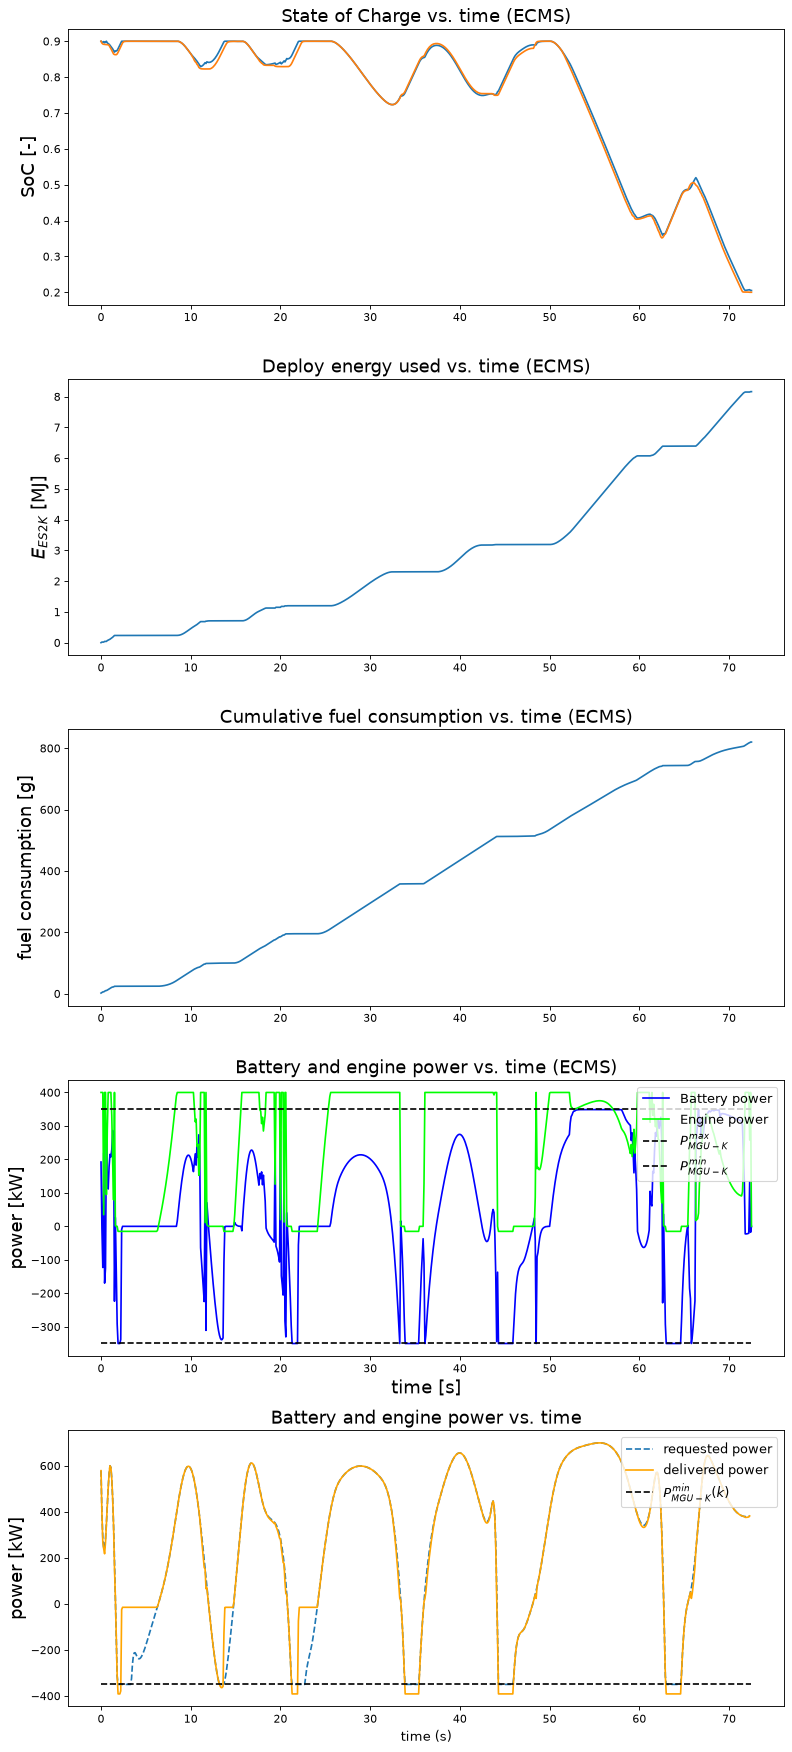

In [6]:
plot.figure(num=5, figsize=(10, 22), dpi=80, facecolor='w', edgecolor='k')

plot.subplot(5,1,1)
plot.plot(t, SoC_ecms, label='ecms')
plot.plot(t, SoC_ref, label='reference from DP')
plot.ylabel('SoC [-]', fontsize=16)
plot.title('State of Charge vs. time (ECMS)', fontsize=16)

plot.subplot(5,1,2)
plot.plot(t, E_ES2K_ecms/1e6)
plot.ylabel('$E_{ES2K}$ [MJ]', fontsize=16)
plot.title('Deploy energy used vs. time (ECMS)', fontsize=16)

plot.subplot(5,1,3)
plot.plot(t, np.cumsum(J_ecms)*1e3)
plot.ylabel('fuel consumption [g]', fontsize=16)
plot.title('Cumulative fuel consumption vs. time (ECMS)', fontsize=16)

plot.subplot(5,1,4)
plot.plot(t, np.array(P_MGUK_ecms)/1e3, 'blue', label='Battery power')
plot.plot(t, np.array(P_eng_ecms)/1e3, 'lime', label='Engine power')
plot.plot(t, P_MGU_max/1e3*np.ones(t.shape), 'k--', label=r'$P_{MGU-K}^{max}$')
plot.plot(t, P_MGU_min/1e3*np.ones(t.shape), 'k--', label=r'$P_{MGU-K}^{min}$')
plot.ylabel('power [kW]', fontsize=16)
plot.xlabel('time [s]', fontsize=16)
plot.title('Battery and engine power vs. time (ECMS)', fontsize=16)
plot.legend(loc=1, fontsize=12)

P_gb2 = np.zeros_like(P_gb)
for k in range(len(P_gb)):
    if P_gb[k]<=P_MGU_min:
        P_gb2[k] = P_MGU_min
    else:
        P_gb2[k]=P_gb[k]

plot.subplot(5,1,5)
plot.plot(t[0:-2], P_gb2[0:-2]/1e3, '--',label='requested power')
plot.plot(t[0:-2], P_mech_MGUK_ecms[0:-2]/1e3 + P_eng_ecms[0:-2]/1e3, 'orange', label='delivered power')
plot.plot(t, P_MGU_min*np.ones(t.shape)/1e3, 'k--', label=r'$P_{MGU-K}^{min}(k)$')
plot.ylabel('power [kW]', fontsize=16)
plot.title('Battery and engine power vs. time', fontsize=16)
plot.xlabel('time (s)', fontsize=12)
plot.tight_layout()
plot.legend(loc=1, fontsize=12)

plot.tight_layout()
plot.show()


### Reading the ECMS results

**State of Charge vs. time** — SoC starts at 0.9 and ends at 0.2046, tracking the DP
reference closely for the whole lap. Both strategies fully deplete the pack: with roughly
4 MJ of usable storage against a 9 MJ deploy allowance, and no terminal constraint, there is
no reason to end a qualifying lap with charge left. The close tracking is what keeps the
instantaneous strategy in the same neighbourhood as the offline-optimal one, and is also
the reason this variant is an upper bound rather than a fully causal controller.

**Deploy energy vs. time** — cumulative deploy reaches 8.163 MJ of the 9 MJ per lap budget.
The budget is not exhausted: the binding constraint is the SoC floor, not the regulatory
allowance.

**Cumulative fuel consumption** — 820.09 g over the lap, against 805.48 g for the DP. The
1.8% penalty is the price of replacing a full-horizon recursion with an instantaneous
minimization, at essentially the same final SoC (0.2046 vs 0.2000) and the same deployed
energy (8.163 vs 8.175 MJ), which is what makes the two figures directly comparable.

**Equivalence factor** — $s$ stays within $[1.90, 2.06]$ with a mean of 1.98, against a
break-even of 2.008. The controller sits just below break-even on average, marginally
favouring the battery, and never leaves the band where the minimum is interior. The
chattering that a mistuned $s_0$ produces is absent.

**Battery and engine power vs. time** — delivered power tracks the request closely during
traction, within the MGU-K bounds throughout. The residual shortfall over the lap is
0.153 MJ, against 0.027 MJ for the DP. Part of the ECMS penalty is therefore paid in
feasibility rather than in fuel: unlike the DP, the instantaneous cost carries no shortfall
term, so the controller has no incentive to avoid leaving demand unmet. Reporting both
columns side by side in `Compare_Controllers.ipynb` keeps that asymmetry visible instead of
hiding it inside the fuel figure.

In [29]:
np.savez('data/qualifying_Canada/ECMS_Canada_qualifying.npz',
         SoC=SoC_ecms, P_MGUK=P_MGUK_ecms, P_eng=P_eng_ecms,
         P_mech_MGUK=P_mech_MGUK_ecms, J=J_ecms,
         E_ES2K=E_ES2K_ecms, shortfall=shortfall, s=s_ecms)